In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    classification_report
)

import joblib

In [3]:
df = pd.read_csv(
    r"C:\Users\sujee\Desktop\Heart_disease prediction1\Heart_Disease_Prediction.csv"
)

# 15. Hyperparameter Tuning

## GridSearchCV

GridSearchCV is used to find the best combination of hyperparameters for the Logistic Regression model.

In this project, different values of the regularization parameter `C` are tested using cross-validation.

In [4]:
df["Heart Disease"] = df["Heart Disease"].map({
    "Absence": 0,
    "Presence": 1
})

In [5]:
X = df.drop("Heart Disease", axis=1)
y = df["Heart Disease"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [7]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000))
])
logistic_model.fit(X_train, y_train)

y_pred = logistic_model.predict(X_test)

y_prob = logistic_model.predict_proba(X_test)[:, 1]

In [8]:
pipeline = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            max_iter=3000
        )
    )
])

In [9]:
param_grid = {
    "model__C": [
        0.01,
        0.1,
        1,
        10,
        100
    ]
}

In [10]:
grid_search = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(
    X_train,
    y_train
)

,estimator,Pipeline(step..._iter=3000))])
,param_grid,"{'model__C': [0.01, 0.1, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


Best Parameter

In [11]:
print(
    "Best Parameters:",
    grid_search.best_params_
)

print(
    "Best CV Score:",
    grid_search.best_score_
)

Best Parameters: {'model__C': 0.01}
Best CV Score: 0.8563424947145876


Final Tuned Model

In [12]:
best_model = grid_search.best_estimator_

final_pred = best_model.predict(
    X_test
)

final_prob = best_model.predict_proba(
    X_test
)[:, 1]

In [13]:
def evaluate_model(name, y_true, y_pred, y_prob):

    print(f"\n{name}")
    print("-" * 40)

    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))
    print("ROC-AUC  :", roc_auc_score(y_true, y_prob))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

In [14]:
evaluate_model(
    "Tuned Logistic Regression",
    y_test,
    final_pred,
    final_prob
)
final_pred = best_model.predict(X_test)

final_prob = best_model.predict_proba(X_test)[:, 1]


Tuned Logistic Regression
----------------------------------------
Accuracy : 0.8518518518518519
Precision: 0.8333333333333334
Recall   : 0.8333333333333334
F1 Score : 0.8333333333333334
ROC-AUC  : 0.9083333333333333

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.87      0.87        30
           1       0.83      0.83      0.83        24

    accuracy                           0.85        54
   macro avg       0.85      0.85      0.85        54
weighted avg       0.85      0.85      0.85        54



**17. Feature Importance**

                    Feature  Coefficient  Absolute
11  Number of vessels fluro     0.249561  0.249561
12                 Thallium     0.247785  0.247785
2           Chest pain type     0.216433  0.216433
8           Exercise angina     0.183258  0.183258
1                       Sex     0.182234  0.182234
9             ST depression     0.165207  0.165207
7                    Max HR    -0.162249  0.162249
10              Slope of ST     0.132409  0.132409
0                       Age     0.075219  0.075219
6               EKG results     0.066837  0.066837
3                        BP     0.060057  0.060057
4               Cholesterol     0.046282  0.046282
5              FBS over 120    -0.032780  0.032780


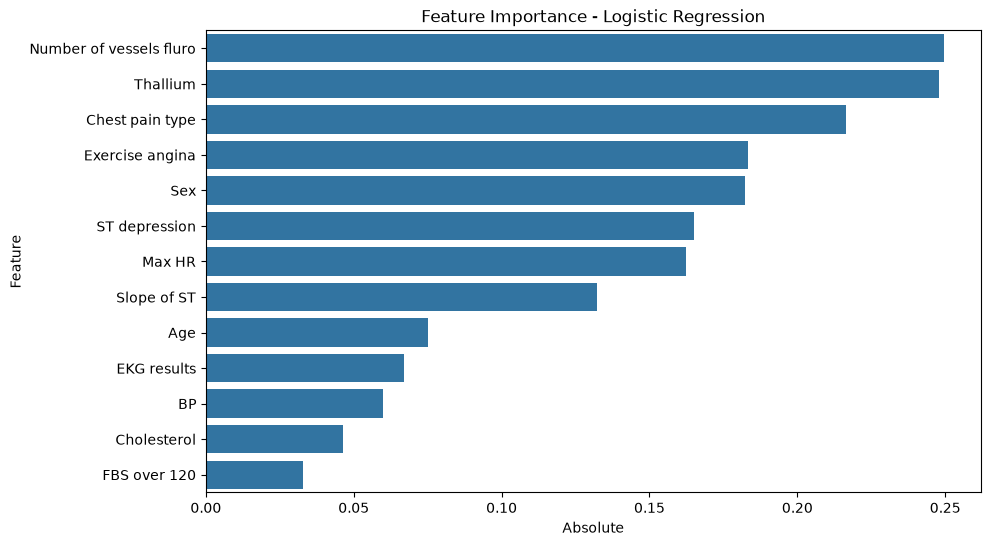

In [19]:
coefficients = best_model.named_steps["model"].coef_[0]

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": coefficients
})

feature_importance["Absolute"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "Absolute",
    ascending=False
)

print(feature_importance)
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Absolute",
    y="Feature"
)

plt.title("Feature Importance - Logistic Regression")

plt.show()

## Conclusion

The tuned Logistic Regression model is evaluated on the test dataset using multiple classification metrics.

Hyperparameter tuning helps identify a better-performing configuration of the model based on cross-validation performance.